**View and run this file on google colab:** [https://colab.research.google.com/github/chetanchandel31/da_phone_pe/blob/main/notebooks/01_phone_pe_analysis.ipynb](https://colab.research.google.com/github/chetanchandel31/da_phone_pe/blob/main/notebooks/01_phone_pe_analysis.ipynb)

**View on Github:** [https://github/chetanchandel31/da_phone_pe/blob/main/notebooks/01_phone_pe_analysis.ipynb](https://github/chetanchandel31/da_phone_pe/blob/main/notebooks/01_phone_pe_analysis.ipynb)

**View nb-viewer:** [https://nbviewer.org/github/chetanchandel31/da_phone_pe/blob/main/notebooks/01_phone_pe_analysis.ipynb](https://nbviewer.org/github/chetanchandel31/da_phone_pe/blob/main/notebooks/01_phone_pe_analysis.ipynb)


In [309]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import ticker


# **1. Data loading and understanding**


### **1.1 Load each dataset and display its structure**


In [310]:
def load_excel_file(sheet_name):
    # using remote url as fallback so it even runs on external environments like google collab
    local_excel_file_path = (
        "../data/raw/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx"
    )
    remote_excel_file_path = "https://raw.githubusercontent.com/chetanchandel31/da_phone_pe/main/data/raw/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx"
    try:
        return pd.read_excel(local_excel_file_path, sheet_name=sheet_name)
    except FileNotFoundError:
        return pd.read_excel(remote_excel_file_path, sheet_name=sheet_name, engine="openpyxl")
    except Exception as e:
        print("unexpected error while loading data", e)
        raise


dfs = {
    "state_txn_users": load_excel_file(sheet_name="State_Txn and Users"),
    "district_txn_users": load_excel_file(sheet_name="District_Txn and Users"),
    "state_txn_type_split": load_excel_file(sheet_name="State_TxnSplit"),
    "state_device_data": load_excel_file(sheet_name="State_DeviceData"),
    "district_demographics": load_excel_file(sheet_name="District Demographics"),
}


---


### 1.1.1 Load the `State_Txn and Users` dataset and display its first 5 rows.


In [311]:
dfs["state_txn_users"].head(5)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


---


### 1.1.2 Load the `State_TxnSplit` dataset and display its bottom 10 rows.


In [312]:
dfs["state_txn_type_split"].tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


---


### 1.1.3 Load the `State_DeviceData` dataset and display 10 rows from the middle of the dataset.


In [313]:
num_rows = dfs["state_device_data"].shape[0]
start_idx = round(num_rows / 2) - 5
end_idx = start_idx + 10
dfs["state_device_data"].iloc[start_idx:end_idx, :]


,State,Year,Quarter,Brand,Registered Users,Percentage
2767,Ladakh,2021,2,OnePlus,1741,0.023198
2768,Ladakh,2021,2,Motorola,922,0.012285
2769,Ladakh,2021,2,Huawei,894,0.011912
2770,Ladakh,2021,2,Lenovo,490,0.006529
2771,Ladakh,2021,2,Others,2610,0.034778
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900


---


### 1.1.4 Load the `District_Txn and Users` dataset and display its first 10 rows and last 10 rows.


In [314]:
print("First 10 rows:")
display(dfs["district_txn_users"].head(10))

print()

print("Last 10 rows:")
display(dfs["district_txn_users"].tail(10))

First 10 rows:


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0



Last 10 rows:


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,1.999694e+10,2324.616616,1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,1.122758e+10,2032.445525,955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,3.041482e+10,1762.331031,2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,8.731263e+09,1784.157359,789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,5.564221e+09,2469.272118,392388,8184990


---


### 1.1.5 Load the `District Demographics` dataset and display every 10th row.


In [315]:
dfs["district_demographics"][::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.0,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North


---


### **1.2 Display basic statistics and data types for each dataset**


### 1.2.1 For each dataset, display the summary statistics (mean, median, std, etc.) for numerical columns.


In [316]:
display(Markdown("**State Txn and Users:**"))
display(dfs["state_txn_users"].describe())

display(Markdown("**District Txn and Users:**"))
display(dfs["district_txn_users"].describe())

display(Markdown("**State Txn Type Split:**"))
display(dfs["state_txn_type_split"].describe())

display(Markdown("**State Device Data:**"))
display(dfs["state_device_data"].describe())

display(Markdown("**District Demographics:**"))
display(dfs["district_demographics"].describe())

**State Txn and Users:**

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.000000,504.000000,5.040000e+02,5.030000e+02,504.000000,5.040000e+02,5.040000e+02
mean,2019.285714,2.357143,4.074000e+07,7.083332e+10,1993.471543,4.777501e+06,9.774471e+07
std,1.031181,1.109971,8.228714e+07,1.440902e+11,607.464894,6.644496e+06,2.042376e+08
min,2018.000000,1.000000,7.780000e+02,1.928611e+06,0.000000,5.010000e+02,0.000000e+00
25%,2018.000000,1.000000,5.925578e+05,1.167157e+09,1598.910667,1.574202e+05,0.000000e+00
50%,2019.000000,2.000000,6.217487e+06,1.051605e+10,1861.380589,1.747914e+06,2.930574e+06
75%,2020.000000,3.000000,4.363675e+07,6.947045e+10,2259.087924,7.320945e+06,8.615022e+07
max,2021.000000,4.000000,5.736165e+08,1.027958e+12,3938.733850,3.966470e+07,1.208084e+09


**District Txn and Users:**

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,10248.000000,10248.000000,1.024800e+04,1.024800e+04,10244.000000,1.024800e+04,1.024800e+04
mean,2019.285714,2.357143,2.003607e+06,3.542311e+09,1909.796545,2.349591e+05,4.807117e+06
std,1.030208,1.108924,9.613466e+06,1.473154e+10,600.943349,4.605978e+05,1.562541e+07
min,2018.000000,1.000000,0.000000e+00,0.000000e+00,84.944283,2.200000e+01,0.000000e+00
25%,2018.000000,1.000000,1.031418e+05,1.756668e+08,1554.589051,3.619550e+04,0.000000e+00
50%,2019.000000,2.000000,3.763065e+05,6.784562e+08,1863.135530,1.067640e+05,6.403025e+05
75%,2020.000000,3.000000,1.272815e+06,2.377256e+09,2203.083552,2.573165e+05,4.346320e+06
max,2021.000000,4.000000,3.487128e+08,4.444224e+11,11209.980550,1.060461e+07,5.544197e+08


**State Txn Type Split:**

,Year,Quarter,Transactions,Amount (INR),ATV (INR)
count,2514.000000,2514.000000,2.514000e+03,2.514000e+03,2514.000000
mean,2019.286794,2.358393,8.167446e+06,1.443978e+10,1349.927929
std,1.030807,1.109251,2.423645e+07,5.995054e+10,1534.866221
min,2018.000000,1.000000,2.000000e+00,3.439721e+01,17.198606
25%,2018.000000,1.000000,2.788075e+04,1.762412e+07,385.735827
50%,2019.000000,2.000000,2.687980e+05,1.901189e+08,720.940406
75%,2020.000000,3.000000,3.683230e+06,2.661248e+09,1352.790116
max,2021.000000,4.000000,2.795990e+08,8.721520e+11,7767.539936


**State Device Data:**

,Year,Quarter,Registered Users,Percentage
count,5544.000000,5544.000000,5.544000e+03,5544.000000
mean,2019.285714,2.357143,4.343183e+05,0.090909
std,1.030250,1.108970,9.056069e+05,0.083095
min,2018.000000,1.000000,1.000000e+01,0.006373
25%,2018.000000,1.000000,8.055750e+03,0.021588
50%,2019.000000,2.000000,7.442250e+04,0.056914
75%,2020.000000,3.000000,3.978875e+05,0.143626
max,2021.000000,4.000000,9.764252e+06,0.478367


**District Demographics:**

,Population,Area (sq km),Density
count,7.420000e+02,742.000000,742.000000
mean,1.668555e+06,4395.373120,838.512129
std,1.458849e+06,4254.676124,2754.406896
min,0.000000e+00,0.000000,0.000000
25%,6.530815e+05,2039.750000,198.000000
50%,1.322359e+06,3402.500000,353.000000
75%,2.297440e+06,5432.750000,686.250000
max,1.008285e+07,45652.000000,36155.000000


---


### 1.2.2 Display the data types of each column in each dataset.


In [317]:
display(Markdown("**State Txn and Users:**"))
display(dfs["state_txn_users"].dtypes)

display(Markdown("**District Txn and Users:**"))
display(dfs["district_txn_users"].dtypes)

display(Markdown("**State Txn Type Split:**"))
display(dfs["state_txn_type_split"].dtypes)

display(Markdown("**State Device Data:**"))
display(dfs["state_device_data"].dtypes)

display(Markdown("**District Demographics:**"))
display(dfs["district_demographics"].dtypes)

**State Txn and Users:**

State                   str
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

**District Txn and Users:**

State                   str
Year                  int64
Quarter               int64
District                str
Code                    str
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

**State Txn Type Split:**

State                   str
Year                  int64
Quarter               int64
Transaction Type        str
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
dtype: object

**State Device Data:**

State                   str
Year                  int64
Quarter               int64
Brand                   str
Registered Users      int64
Percentage          float64
dtype: object

**District Demographics:**

State                 str
District              str
Headquarters          str
Population          int64
Area (sq km)      float64
Density             int64
Code                  str
Alternate Name        str
dtype: object

---


### **1.3 Check for missing values**


### 1.3.1 Identify any missing values in each dataset.


In [318]:
for df_name, df in dfs.items():
    display(Markdown(f"#### **For {df_name}:**"))

    display(Markdown("**Columns with null values**"))
    df_cols_to_nan_count = df.isna().sum()
    display(df_cols_to_nan_count[df_cols_to_nan_count > 0])

    display(Markdown("**Numeric columns with 0s**"))
    df_num_cols_to_zero_count = (df.select_dtypes(include="number") == 0).sum()
    display(df_num_cols_to_zero_count[df_num_cols_to_zero_count > 0])

    print()

#### **For state_txn_users:**

**Columns with null values**

Amount (INR)    1
dtype: int64

**Numeric columns with 0s**

ATV (INR)      1
App Opens    180
dtype: int64

...

#### **For district_demographics:**

**Columns with null values**

Series([], dtype: int64)

**Numeric columns with 0s**

Population      14
Area (sq km)    15
Density         18
dtype: int64

For each sheet, we will investigate in the upcoming sections whether the `0`s represent genuine zero values or are being used as placeholders for missing values, and whether the actual `null` values should be imputed, dropped, or retained.


---


### 1.3.2 Calculate the percentage of missing values for each column that has missing values.

and

### 1.3.3 Highlight which column has the highest percentage of missing values in each dataset.


In [319]:
for sheet, df in dfs.items():
    display(Markdown(f"#### **{sheet}**"))
    cols = df.columns

    missing_value_col_names = []
    missing_value_percent_in_col = []
    zero_value_col_names = []

    for col in cols:
        null_count = df[col].isna().sum()
        zero_count = (df[col] == 0).sum()
        total = len(df[col])

        if null_count > 0 or zero_count > 0:
            null_pct = round(null_count * 100 / total, 2)
            zero_pct = round(zero_count * 100 / total, 2)
            display(Markdown(f"**`{col}`**: **{null_pct}%** missing (null) | **{zero_pct}%** zero"))

        if null_count > 0:
            missing_value_col_names.append(col)
            missing_value_percent_in_col.append(null_pct)

        if zero_count > 0:
            zero_value_col_names.append(col)

    if len(missing_value_col_names) > 0:
        missing_value_percent_in_col = np.array(missing_value_percent_in_col)
        col_highest_missing_value_percent = missing_value_col_names[
            missing_value_percent_in_col.argmax()
        ]
        display(
            Markdown(
                f"In **'{sheet}'**, **`{col_highest_missing_value_percent}`** column has the highest % of missing (null) values: **{max(missing_value_percent_in_col)}%**."
            )
        )
    if len(missing_value_col_names) == 0 and len(zero_value_col_names) == 0:
        display(Markdown("*no columns with null values in this dataset.*"))
    print()

#### **state_txn_users**

**`Amount (INR)`**: **0.2%** missing (null) | **0.0%** zero

**`ATV (INR)`**: **0.0%** missing (null) | **0.2%** zero

**`App Opens`**: **0.0%** missing (null) | **35.71%** zero

In **'state_txn_users'**, **`Amount (INR)`** column has the highest % of missing (null) values: **0.2%**.

...

*no columns with null values in this dataset.*

#### **district_demographics**

**`Population`**: **0.0%** missing (null) | **1.89%** zero

**`Area (sq km)`**: **0.0%** missing (null) | **2.02%** zero

**`Density`**: **0.0%** missing (null) | **2.43%** zero

Here, we've treated `null` values as "missing" and reported `0` values separately, since whether a `0` represents genuine missing data will be investigated separately later during data cleaning, not something safe to assume uniformly here.


---


### **1.4 Create a summary**


### 1.4.1 Calculate the total number of states and the total number of districts.


In [320]:
df = dfs["district_demographics"]

display(Markdown(f"**Total no. of states:** {df['State'].nunique()}"))

# to ensure same name districts from diff states get counted
display(
    Markdown(f"**Total no. of districts:** {df[['State', 'District']].drop_duplicates().shape[0]}")
)


**Total no. of states:** 36

**Total no. of districts:** 742

We get 36 states because we have 28 Indian states + 8 union territories in `States` column.


---


### 1.4.2 Identify the state with the highest number of districts.


In [321]:
df = dfs["district_demographics"]

state_to_district_count = df["State"].value_counts()

highest_district_state = state_to_district_count.idxmax()

display(
    Markdown(
        f"**{highest_district_state}** has the highest number of districts: **{state_to_district_count[highest_district_state]}**"
    )
)

**Uttar Pradesh** has the highest number of districts: **75**

---


### **1.5 Data cleaning**


#### **_null value in `Amount (INR)` column in "State_Txn and Users"_**


In [322]:
df = dfs["state_txn_users"]
# inspecting missing value row
display(Markdown("Row with null `Amount (INR)`:"))
display(df[df["Amount (INR)"].isna()])

# andhra pradesh entries from 2020 q3, 2020 q4 and 2021 q2
mask = ((df["State"] == "Andhra Pradesh") & (df["Year"] == 2021) & (df["Quarter"] == 2)) | (
    (df["State"] == "Andhra Pradesh") & (df["Year"] == 2020) & (df["Quarter"].isin([3, 4]))
)

display(Markdown("Surrounding entries used for average `Amount (INR)` calculation:"))
display(df[mask])

avg_atv_from_surrounding_entries = df[mask]["ATV (INR)"].mean()

mask_missing_amount_row = (
    (df["State"] == "Andhra Pradesh") & (df["Year"] == 2021) & (df["Quarter"] == 1)
)
df.loc[mask_missing_amount_row, "ATV (INR)"] = avg_atv_from_surrounding_entries
df.loc[mask_missing_amount_row, "Amount (INR)"] = (
    df[mask_missing_amount_row]["Transactions"] * avg_atv_from_surrounding_entries
)

display(Markdown("Row after imputation of missing `Amount (INR)` and `ATV(INR)`:"))
display(df.loc[mask_missing_amount_row])


Row with null `Amount (INR)`:

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
26,Andhra Pradesh,2021,1,289747970,NaN,0.0,18363733,957709447


Surrounding entries used for average `Amount (INR)` calculation:

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
24,Andhra Pradesh,2020,3,204902935,4.670841e+11,2279.538507,15692405,696300382
25,Andhra Pradesh,2020,4,286118552,6.548415e+11,2288.707046,17076565,869078538
27,Andhra Pradesh,2021,2,352767134,8.507375e+11,2411.612129,19620905,1044705436


Row after imputation of missing `Amount (INR)` and `ATV(INR)`:

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
26,Andhra Pradesh,2021,1,289747970,6.741332e+11,2326.619228,18363733,957709447


There was just 1 entry (for Andhra Pradesh's Q1 2021) where `Amount (INR)` was `null` and as a result, `ATV (INR)` was `0`.

As a reasonable approximation, we treated ATV as roughly stable across nearby quarters for Andhra Pradesh. We looked at entries for surrounding periods (entries for Andhra Pradesh from 2020 q3, 2020 q4 and 2021 q2) to calculate the average `ATV (INR)` and used it to estimate the missing `ATV (INR)` value.

Then, we used `Amount = Transactions x ATV` to calculate the value for the `Amount (INR)` column since `ATV (INR)` was calculated as `ATV = Amount / Transactions`.


---


#### **_0 values in `App Opens` column in "State_Txn and Users" and "District_Txn and Users"_**


In [323]:
df_state_transaction_data = dfs["state_txn_users"]
df_district_transaction_data = dfs["district_txn_users"]

display(Markdown("Year-Quarter combinations with 0 `App Opens` in 'State_Txn and Users' dataset:"))
df_state_app_opens_by_quarter = (
    df_state_transaction_data.groupby(["Year", "Quarter"])["App Opens"]
    .apply(lambda x: (x == 0).sum())
    .reset_index()
    .rename(columns={"App Opens": "Rows with 0 App Opens"})
)
display(df_state_app_opens_by_quarter[df_state_app_opens_by_quarter["Rows with 0 App Opens"] > 0])

display(
    Markdown("Year-Quarter combinations with 0 `App Opens` in 'District_Txn and Users' dataset:")
)
df_district_app_opens_by_quarter = (
    df_district_transaction_data.groupby(["Year", "Quarter"])["App Opens"]
    .apply(lambda x: (x == 0).sum())
    .reset_index()
    .rename(columns={"App Opens": "Rows with 0 App Opens"})
)
display(
    df_district_app_opens_by_quarter[df_district_app_opens_by_quarter["Rows with 0 App Opens"] > 0]
)

df_state_transaction_data["App Opens"] = df_state_transaction_data["App Opens"].replace(0, np.nan)
df_district_transaction_data["App Opens"] = df_district_transaction_data["App Opens"].replace(
    0, np.nan
)

Year-Quarter combinations with 0 `App Opens` in 'State_Txn and Users' dataset:

,Year,Quarter,Rows with 0 App Opens
0,2018,1,36
1,2018,2,36
2,2018,3,36
3,2018,4,36
4,2019,1,36


Year-Quarter combinations with 0 `App Opens` in 'District_Txn and Users' dataset:

,Year,Quarter,Rows with 0 App Opens
0,2018,1,732
1,2018,2,732
2,2018,3,732
3,2018,4,732
4,2019,1,732


- As we can see, all rows with 0 `App Opens`, from EVERY state and EVERY district in _"State_Txn and Users"_ and _"District_Txn and Users"_ datasets respectively, only occur in the initial few quarters (Q1 2018 to Q1 2019).
- This strongly suggests that the `App Opens` metric wasn't tracked/reported from day one, it was added to their reporting later than `Transactions`, `Amount (INR)` and `Registered Users`. So "0"s here likely mean "not measured yet," not "genuinely zero activity".
- Hence, we've replaced all `0`s in this column with `nan`s to clearly flag them as "not available" rather than treating 0 as a real observed value, because using `NaN` generally allows pandas' aggregation functions to exclude these values from calculations rather than treating them as genuine zero observations.


---


#### **_null values in `Code` column in "District_Txn and Users"_**


In [324]:
df_district_transaction_data = dfs["district_txn_users"]
df_district_demographics = dfs["district_demographics"]

df_district_rows_missing_code = df_district_transaction_data[
    df_district_transaction_data["Code"].isna()
]
display(Markdown(f"*Number of rows with missing `Code`*: {len(df_district_rows_missing_code)}"))
districts_without_code = df_district_rows_missing_code["District"].unique()
display(
    Markdown(
        f"*Unique districts associated with missing `Code` rows*: {', '.join(districts_without_code)}"
    )
)

display(
    Markdown("*`Code` associated with missing districts from 'District Demographics' dataset:*")
)
for district in districts_without_code:
    code_list = df_district_demographics[df_district_demographics["District"] == district][
        "Code"
    ].values
    display(Markdown(f"*{district}:* {code_list[0] if len(code_list) > 0 else 'None'}"))

*Number of rows with missing `Code`*: 28

*Unique districts associated with missing `Code` rows*: Mirpur, Muzaffarabad

*`Code` associated with missing districts from 'District Demographics' dataset:*

*Mirpur:* None

*Muzaffarabad:* None

PhonePe uses its own conventions for district codes, like JK01, JK02 etc.

Since we couldn't find district codes for these districts in the `"District Demographics"` sheet either, we will retain the missing `Code` values as guessing their internal district code conventions without them being provided anywhere in the dataset would be incorrect.


---


#### **_missing values in `Transactions`, `Amount (INR)` and `ATV (INR)` columns in "District_Txn and Users"_**


In [325]:
df = dfs["district_txn_users"]
display(Markdown("**Rows with 0 `Transactions`, `Amount (INR)` or null `ATV (INR)` columns:**"))
display(df[df["ATV (INR)"].isna() | (df["Transactions"] == 0) | (df["Amount (INR)"] == 0)])

df_district_demographics = dfs["district_demographics"]
display(Markdown("**Top 3 districts with lowest population across entire dataset:**"))
df_district_demographics[df_district_demographics["Population"] > 0].sort_values(
    by=["Population"], ascending=[True]
).head(3)[["State", "District", "Population"]]


**Rows with 0 `Transactions`, `Amount (INR)` or null `ATV (INR)` columns:**

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
224,Arunachal Pradesh,2018,1,Anjaw,AR01,0,0.0,NaN,278,NaN
241,Arunachal Pradesh,2018,1,Shi Yomi,AR17,0,0.0,NaN,49,NaN
266,Arunachal Pradesh,2018,2,Shi Yomi,AR17,0,0.0,NaN,80,NaN
291,Arunachal Pradesh,2018,3,Shi Yomi,AR17,0,0.0,NaN,118,NaN


**Top 3 districts with lowest population across entire dataset:**

,State,District,Population
33,Arunachal Pradesh,Upper Dibang Valley,7948
29,Arunachal Pradesh,Shi Yomi,13310
13,Arunachal Pradesh,Anjaw,21089


Since all the rows with missing `Transactions`, `Amount (INR)` and `ATV (INR)` columns belong to "Shi Yomi" and "Anjaw" which are also among the top 3 districts with lowest population (not just in Arunachal Pradesh but across all states) as per our dataset, it is reasonable to assume that the 0 `Transactions` and `Amount (INR)` values represent genuinely no/very little PhonePe transactions rather than missing data.

Hence, we won't try imputing the `0`s in `Amount (INR)` and `Transactions`. The `NaN`s in `ATV (INR)` won't be replaced with 0s either to avoid giving a false impression of transactions existing but having 0 average value.


---


#### **_0s in `Population`, `Area (sq km)` and `Density` in "district_demographics"_**


In [326]:
df = dfs["district_demographics"]
cols = ["Population", "Area (sq km)", "Density"]
mask_one_col_missing = (df[cols] == 0).sum(axis=1) == 1

display(Markdown("**Rows with only 1 column missing:**"))
df_1_col_missing = df[mask_one_col_missing]
display(df_1_col_missing)

# just for safety, condition will always pass, we've inspected there's only 1 row here with `Density` missing
assert (df_1_col_missing["Density"] == 0).sum() == len(df_1_col_missing), (
    "Assumption broken: not all rows in `df_1_col_missing` have Density==0"
)
df.loc[df_1_col_missing.index, "Density"] = round(
    df_1_col_missing["Population"] / df_1_col_missing["Area (sq km)"]
)

mask_has_cols_with_zero = (df[cols] == 0).sum(axis=1) > 0
df_rows_with_zeroes = df[mask_has_cols_with_zero]
display(
    Markdown(f"**Rows remaining with 0s:** {len(df_rows_with_zeroes)}")
)  # we already know from previous section. only the cols `population`, `area` and `density` have zeroes

display(Markdown("**Sample of rows with 0s:**"))
display(df_rows_with_zeroes.head(5))

df[mask_has_cols_with_zero] = df[mask_has_cols_with_zero].replace(0, np.nan)


**Rows with only 1 column missing:**

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
375,Manipur,Kangpokpi,Kangpokpi,193744,1698.0,0,MN09,Kangpokpi


**Rows remaining with 0s:** 17

**Sample of rows with 0s:**

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
18,Arunachal Pradesh,Kra Daadi,Jamin,0,0.0,0,AR06,Kra Daadi
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
24,Arunachal Pradesh,Lower Siang,Likabali,0,0.0,0,AR12,Lower Siang
27,Arunachal Pradesh,Pakke-Kessang,Lemmi,0,0.0,0,AR15,Pakke Kessang
39,Assam,Bajali,Pathsala,253816,0.0,0,AS01,Bajali


Since `Population`, `Area (sq km)` and `Density` can not truly be 0, we have replaced these 0 values with `NaN` to represent them as genuinely unavailable rather than treating them as valid zero values.

For 1 row, where only 1 value (`Density`) among these 3 was missing, we've imputed it with an estimate using the formula `Density = Population / Area` instead of replacing it with `NaN`.


---


# **2. Exploratory Data Analysis (EDA)**


### **2.1 Analyze transaction trends over the years for each state**


### 2.1.1 Calculate the total number of transactions and total transaction amount for each state over the years. Display the results in a tabular format.


In [327]:
df = dfs["state_txn_users"]

df.groupby("State").agg({"Transactions": "sum", "Amount (INR)": "sum"}).rename(
    columns={
        "Transactions": "Total transaction count",
        "Amount (INR)": "Total transaction amount",
    }
)

,Total transaction count,Total transaction amount
State,,
Andaman & Nicobar Islands,1223565,3.641818e+09
Andhra Pradesh,1781091169,3.861981e+12
Arunachal Pradesh,8043799,2.225183e+10
Assam,123577981,2.814087e+11
Bihar,713643889,1.639579e+12
Chandigarh,25516542,5.371208e+10
Chhattisgarh,241908549,4.156353e+11
Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10
Delhi,1011031124,1.649942e+12


---


### 2.1.2 Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes. Display the results.


In [328]:
df = dfs["state_txn_users"]

df_state_to_total_transactions = (
    df.groupby("State")
    .agg({"Transactions": "sum"})
    .rename(columns={"Transactions": "Total transactions"})
).sort_values(by="Total transactions", ascending=False)

display(Markdown("**5 states with the highest transaction volumes are:**"))
display(df_state_to_total_transactions.head(5))

display(Markdown("**5 states with the lowest transaction volumes are:**"))
display(df_state_to_total_transactions.tail(5))


**5 states with the highest transaction volumes are:**

,Total transactions
State,
Karnataka,2981044533
Maharashtra,2833670154
Telangana,2347430243
Andhra Pradesh,1781091169
Rajasthan,1382918930


**5 states with the lowest transaction volumes are:**

,Total transactions
State,
Meghalaya,5648913
Mizoram,2162776
Ladakh,1880109
Andaman & Nicobar Islands,1223565
Lakshadweep,71610


**Note:** "transaction volume" here is interpreted as "number of transactions", not "transaction amount.".


---


### **2.2 Identify the most common transaction types in each state and quarter**


### 2.2.1 For each state and quarter, determine the most frequent transaction type. Display the results in a tabular format.


In [329]:
df = dfs["state_txn_type_split"]

df_most_frequent_transaction_type = (
    df.groupby(["State", "Year", "Quarter"])
    .apply(lambda x: x.loc[x["Transactions"].idxmax(), ["Transaction Type", "Transactions"]])
    .reset_index()
    .rename(columns={"Transactions": "Transaction count"})
)

df_most_frequent_transaction_type["Quarter"] = (
    "Q"
    + df_most_frequent_transaction_type["Quarter"].astype(str)
    + " - "
    + df_most_frequent_transaction_type["Year"].astype(str)
)

df_most_frequent_transaction_type = df_most_frequent_transaction_type.drop(columns="Year")

df_most_frequent_transaction_type

,State,Quarter,Transaction Type,Transaction count
0,Andaman & Nicobar Islands,Q1 - 2018,Recharge & bill payments,4200
1,Andaman & Nicobar Islands,Q2 - 2018,Recharge & bill payments,6735
2,Andaman & Nicobar Islands,Q3 - 2018,Recharge & bill payments,8636
3,Andaman & Nicobar Islands,Q4 - 2018,Recharge & bill payments,11517
4,Andaman & Nicobar Islands,Q1 - 2019,Recharge & bill payments,15263
...,...,...,...,...
499,West Bengal,Q2 - 2020,Peer-to-peer payments,24855687
500,West Bengal,Q3 - 2020,Peer-to-peer payments,37556349
501,West Bengal,Q4 - 2020,Peer-to-peer payments,46437233
502,West Bengal,Q1 - 2021,Peer-to-peer payments,53869075


---


### **2.3: Determine the device brand with the highest number of registered users in each state**


### 2.3.1 Identify the device brand with the highest number of registered users in each state. Display the results in a tabular format.


In [330]:
df = dfs["state_device_data"]

df_state_brand_users = df.groupby(["State", "Brand"])["Registered Users"].sum().reset_index()

df_state_brand_highest_users = df_state_brand_users.groupby("State").apply(
    lambda x: x.loc[x["Registered Users"].idxmax()]
)


display(Markdown("**Brand with highest number of users in each state:**"))
display(df_state_brand_highest_users)

display(Markdown("**Number of states where brand has the highest registered users:**"))
display(
    df_state_brand_highest_users["Brand"]
    .value_counts()
    .reset_index()
    .rename(columns={"Brand": "Highest user brand", "count": "number of states"})
)

display(Markdown("**State where Samsung has the highest number of registered users:**"))
display(df_state_brand_highest_users[df_state_brand_highest_users["Brand"] == "Samsung"])

**Brand with highest number of users in each state:**

,Brand,Registered Users
State,,
Andaman & Nicobar Islands,Xiaomi,97889
Andhra Pradesh,Xiaomi,40061549
Arunachal Pradesh,Xiaomi,437803
Assam,Xiaomi,6979357
Bihar,Xiaomi,33721314
Chandigarh,Xiaomi,896628
Chhattisgarh,Xiaomi,8763373
Dadra & Nagar Haveli and Daman & Diu,Xiaomi,638834
Delhi,Xiaomi,24114984


**Number of states where brand has the highest registered users:**

,Highest user brand,number of states
0,Xiaomi,35
1,Samsung,1


**State where Samsung has the highest number of registered users:**

,Brand,Registered Users
State,,
Sikkim,Samsung,406392


**Interesting find:** Xiaomi is the brand with the highest number of users in 35 of 36 states, Samsung takes the lead in just one, which is Sikkim.


---


### **2.4 Create a list of the top district per state based on population**


### 2.4.1 For each state, identify the district with the highest population. Display the results in a tabular format.


In [331]:
df = dfs["district_demographics"]

df_district_highest_population = (
    df.groupby("State")
    .apply(lambda x: x.loc[x["Population"].idxmax(), ["District", "Population"]])
    .reset_index()
)

df_district_highest_population = df_district_highest_population.rename(
    columns={"District": "Highest population district"}
)

display(Markdown("**District with highest population for each state:**"))
display(df_district_highest_population)

**District with highest population for each state:**

,State,Highest population district,Population
0,Andaman & Nicobar Islands,South Andaman,238142.0
1,Andhra Pradesh,East Godavari,5151549.0
2,Arunachal Pradesh,Papum Pare,176385.0
3,Assam,Nagaon,2826006.0
4,Bihar,Patna,5772804.0
5,Chandigarh,Chandigarh,1055450.0
6,Chhattisgarh,Raipur,2160876.0
7,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,343709.0
8,Delhi,North West Delhi,3656539.0
9,Goa,North Goa,817761.0


---


### 2.4.2 Create a column chart depicting the district with the highest population for each state.


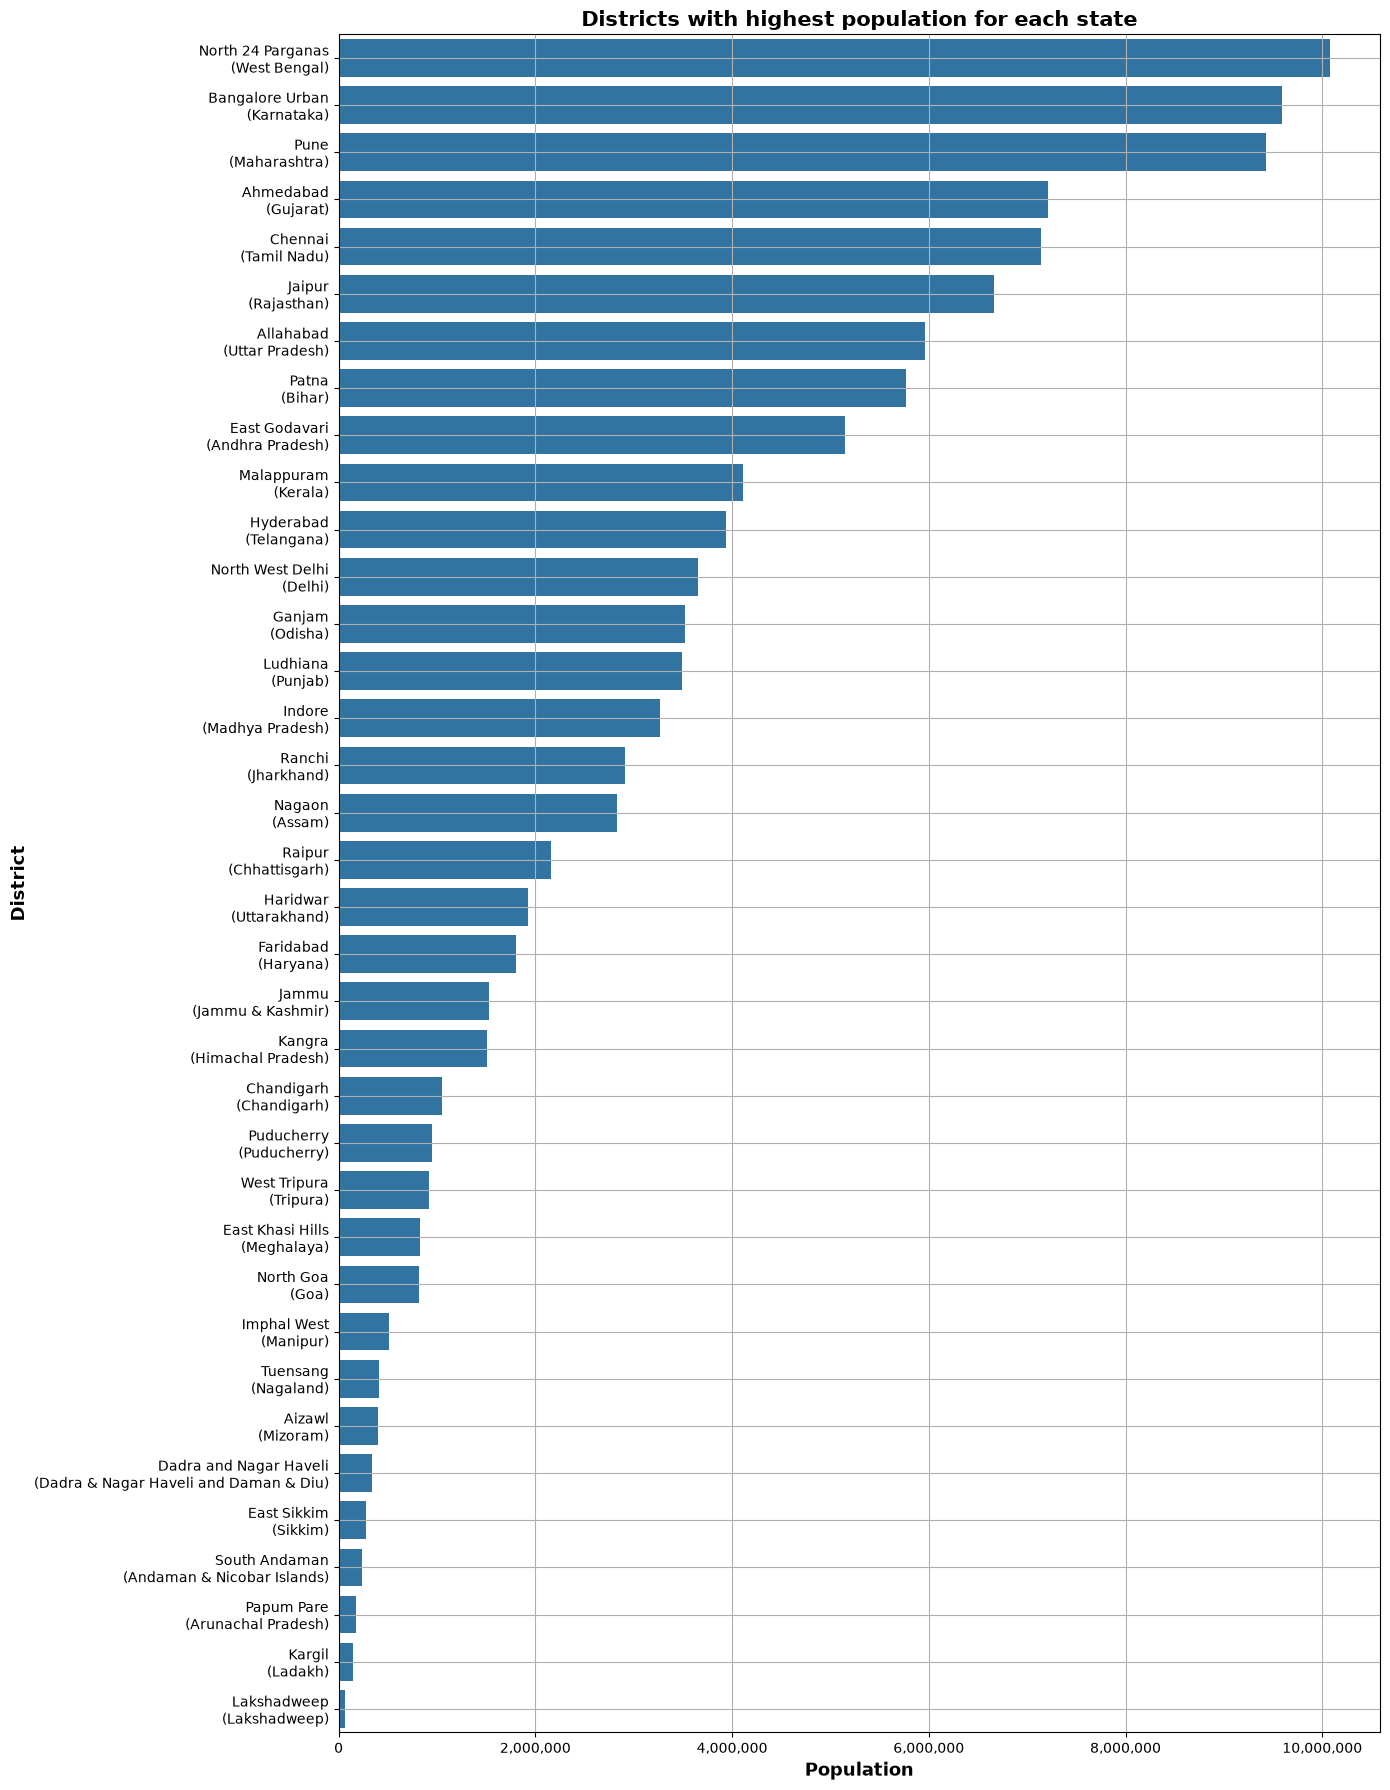

In [332]:
df_chart = df_district_highest_population.copy()
df_chart["Highest population district"] = (
    df_chart["Highest population district"] + "\n(" + df_chart["State"] + ")"
)

df_chart = df_chart.drop(columns="State")

df_chart = df_chart.sort_values(by="Population", ascending=False)

plt.figure(figsize=(14, 18))
sns.barplot(df_chart, x="Population", y="Highest population district")

plt.xlabel("Population", fontsize=13, fontweight="bold")
plt.ylabel("District", fontsize=13, fontweight="bold")
plt.title("Districts with highest population for each state", fontsize=15, fontweight="bold")

# show normal numbers on x axis not scientific notation
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.grid()
plt.tight_layout()
plt.show()

**Note:** used horizontal bar chart instead of vertical for label readability due to 36 categories


---


### **2.5 Calculate the average transaction value (ATV) for each state**


### 2.5.1 Compute the average transaction value for each state. Display the results in a tabular format.


In [333]:
df = dfs["state_txn_users"]

df_state_atv = df.groupby("State")[["Transactions", "Amount (INR)"]].sum().reset_index()

df_state_atv["ATV"] = (df_state_atv["Amount (INR)"] / df_state_atv["Transactions"]).round(2)
df_state_atv = df_state_atv.drop(columns=["Transactions", "Amount (INR)"])

display(df_state_atv)

,State,ATV
0,Andaman & Nicobar Islands,2976.40
1,Andhra Pradesh,2168.32
2,Arunachal Pradesh,2766.33
3,Assam,2277.18
4,Bihar,2297.47
5,Chandigarh,2104.99
6,Chhattisgarh,1718.15
7,Dadra & Nagar Haveli and Daman & Diu,1497.23
8,Delhi,1631.94
9,Goa,1808.37


---


### 2.5.2 Identify the top 5 states with the highest ATV and the top 5 states with the lowest ATV. Display the results.


In [334]:
df_state_atv = df_state_atv.sort_values(by="ATV", ascending=False)

display(Markdown("**Top 5 states with highest ATV:**"))
display(df_state_atv.head(5))

display(Markdown("**Top 5 states with lowest ATV:**"))
display(df_state_atv.tail(5))

**Top 5 states with highest ATV:**

,State,ATV
17,Ladakh,3514.15
0,Andaman & Nicobar Islands,2976.40
23,Mizoram,2920.85
21,Manipur,2905.76
24,Nagaland,2794.14


**Top 5 states with lowest ATV:**

,State,ATV
8,Delhi,1631.94
35,West Bengal,1541.68
20,Maharashtra,1514.29
7,Dadra & Nagar Haveli and Daman & Diu,1497.23
15,Karnataka,1463.04


---


### **2.6 Analyze app usage trends**


### 2.6.1 Calculate the total number of app opens over the years and quarters for each state. Display the results in a tabular format.


In [335]:
df = dfs["state_txn_users"]

display(df.groupby("State").agg({"App Opens": "sum"}))

,App Opens
State,
Andaman & Nicobar Islands,5.554749e+06
Andhra Pradesh,5.352180e+09
Arunachal Pradesh,3.673888e+07
Assam,3.816996e+08
Bihar,2.043130e+09
Chandigarh,4.347844e+07
Chhattisgarh,7.768177e+08
Dadra & Nagar Haveli and Daman & Diu,3.944105e+07
Delhi,1.580570e+09


---


### 2.6.2 Identify trends in app usage by creating a line plot showing the number of app opens over time for a selected state.


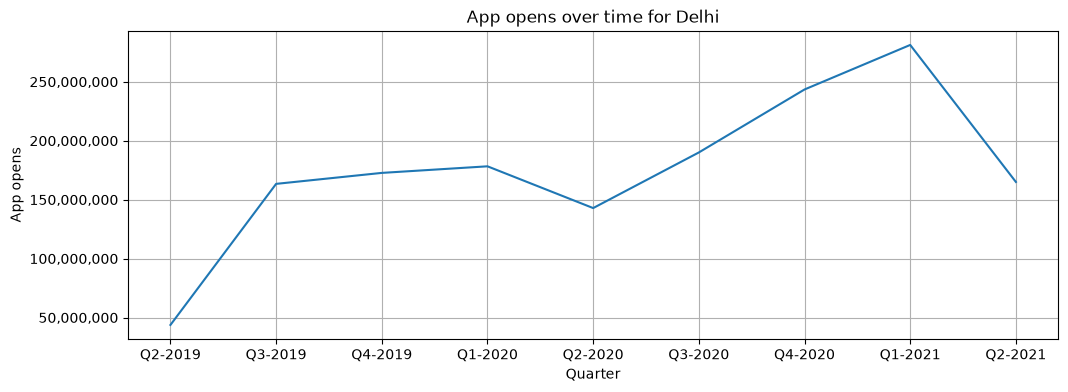

In [336]:
selected_state = "Delhi"
df = dfs["state_txn_users"]
df_selected_state = df[df["State"] == selected_state].copy()

# not really needed because dataset is already sorted by state -> year -> quarter
df_selected_state = df_selected_state.sort_values(by=["Year", "Quarter"], ascending=True)

df_selected_state["Period"] = (
    "Q" + df_selected_state["Quarter"].astype(str) + "-" + df_selected_state["Year"].astype(str)
)

plt.figure(figsize=(12, 4))
sns.lineplot(df_selected_state, x="Period", y="App Opens")

plt.title(f"App opens over time for {selected_state}")
plt.xlabel("Quarter")
plt.ylabel("App opens")

# show normal numbers on y axis not scientific notation
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.grid()
plt.show()


**Note:** The chart starts from Q2-2019 instead of Q1-2018 because in data cleaning section, we discovered this metric wasn't being tracked for any state from Q1-2018 to Q1-2019 and imputed all 0 values with `NaN` to correctly represent unavailable values


---


### **2.7 Distribution of transaction types**


### 2.7.1 Create a bar chart showing the distribution of different transaction types for each state for the most recent quarter in the dataset.


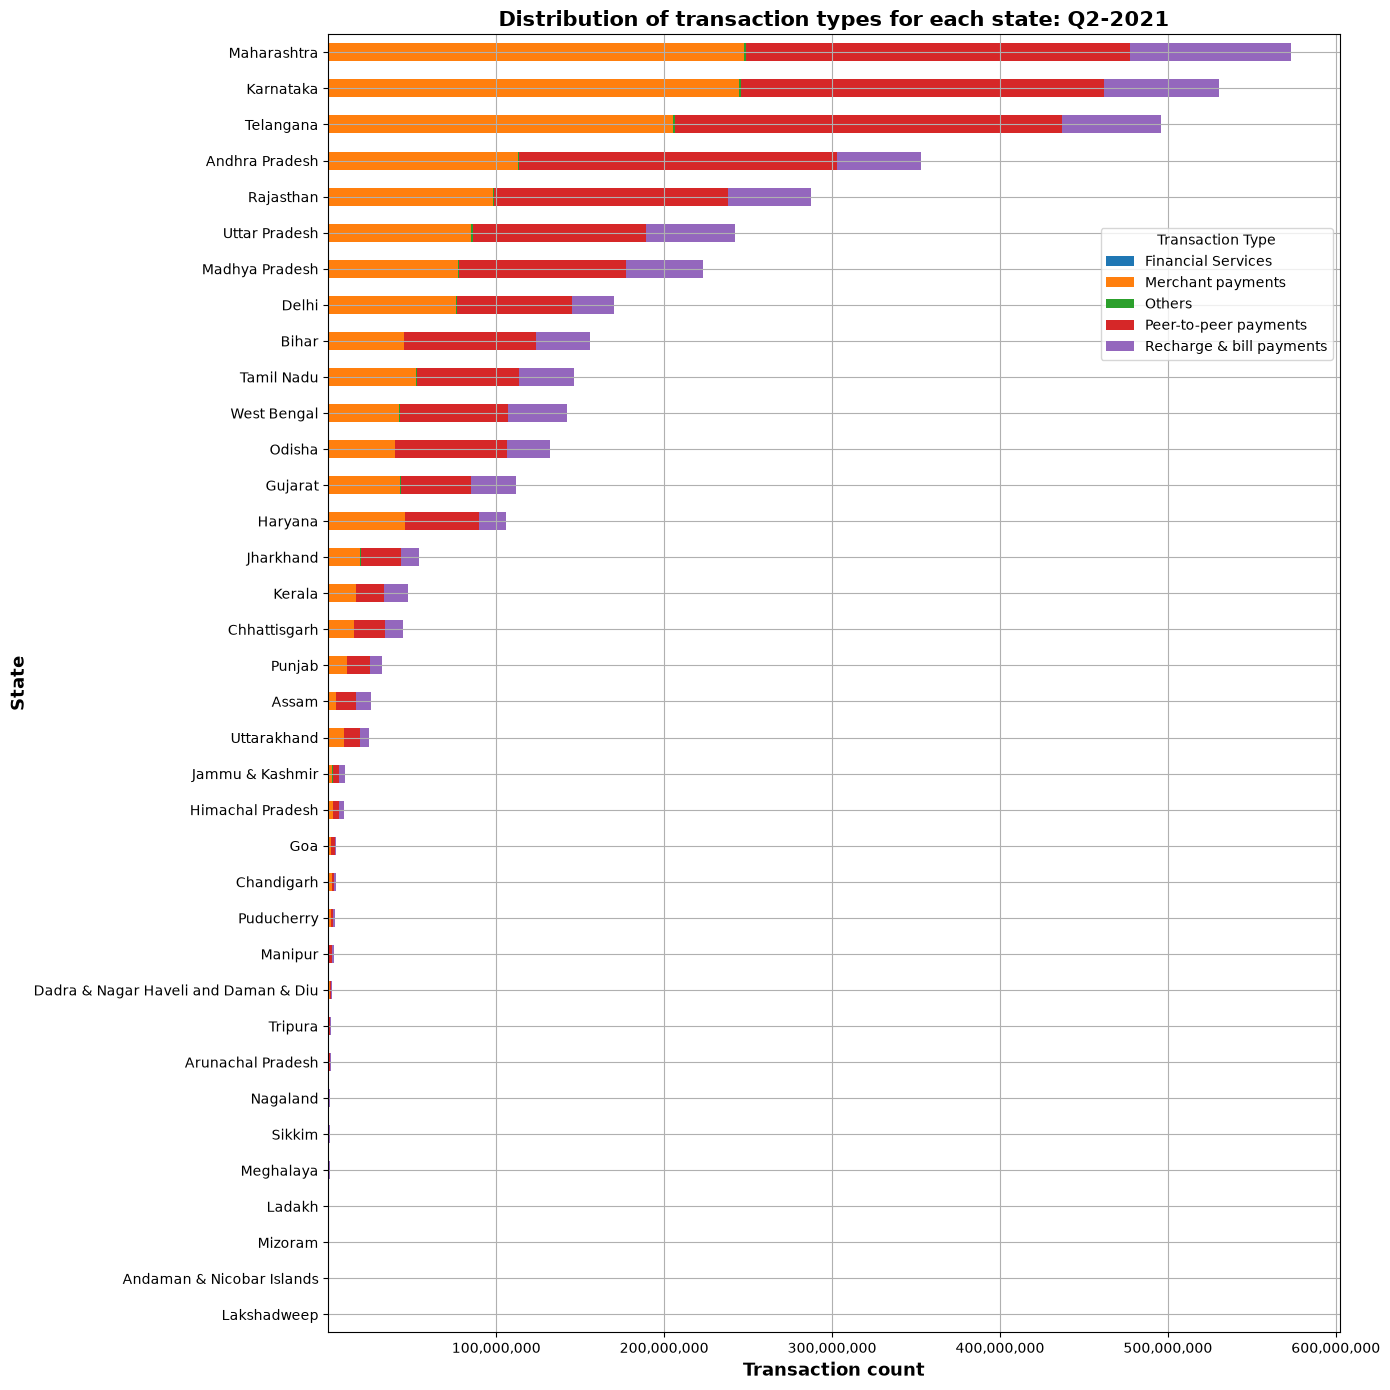

In [337]:
df = dfs["state_txn_type_split"]

most_recent_year = df["Year"].max()
most_recent_quarter = df[df["Year"] == most_recent_year]["Quarter"].max()

df = df[(df["Year"] == most_recent_year) & (df["Quarter"] == most_recent_quarter)]

df = df.pivot_table(index="State", columns="Transaction Type", values="Transactions", aggfunc="sum")

df = df.loc[df.sum(axis=1).sort_values(ascending=True).index]

# stacked bar chart(horizontal)
df.plot(kind="barh", stacked=True, figsize=(14, 14))

plt.xlabel("Transaction count", fontsize=13, fontweight="bold")
plt.ylabel("State", fontsize=13, fontweight="bold")
plt.title(
    f"Distribution of transaction types for each state: Q{most_recent_quarter}-{most_recent_year}",
    fontsize=15,
    fontweight="bold",
)

# show normal numbers on x axis not scientific notation
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.grid()
plt.tight_layout()
plt.legend(title="Transaction Type", loc="center right", bbox_to_anchor=(1.0, 0.8))
plt.show()


---


### **2.8 Find unique mapping between district name and district code**


### 2.8.1 Identify the unique mapping between district names and district codes from the dataset.


In [338]:
df = dfs["district_txn_users"]
df_district_name_to_code = df[["District", "Code"]].drop_duplicates()

display(Markdown("**Sample of district name and code mapping:**"))
display(df_district_name_to_code.head())

**Sample of district name and code mapping:**

,District,Code
0,Nicobars,AN01
1,North And Middle Andaman,AN02
2,South Andaman,AN03
42,Anantapur,AP01
43,Chittoor,AP02


---


### 2.8.2 Create a CSV file containing the unique district name and district code mappings.

and

### 2.8.3 Export the CSV file.


In [339]:
os.makedirs("../data/processed", exist_ok=True)  # create folder if it doesnt exist
df_district_name_to_code.to_csv("../data/processed/district_name_code_mapping.csv", index=False)

Since this exported CSV is part of this project's github repo, it can be viewed here: [District name to code mapping (CSV)](https://raw.githubusercontent.com/chetanchandel31/da_phone_pe/main/data/processed/district_name_code_mapping.csv)


---


# **3. Data Quality Checks**


### **3.1 Ensure data consistency across state and district levels**


### 3.1.1 For each state, calculate the total number of transactions, total transaction amount, and total registered users by summing up the values from the district level data.


In [340]:
df = dfs["district_txn_users"]

dict_renamed_cols = {
    "Transactions": "Total transactions count",
    "Amount (INR)": "Total transaction amount",
    "Registered Users": "Total registered users",
}

df_state_stats_from_district_transactions = (
    df.groupby("State")[["Transactions", "Amount (INR)", "Registered Users"]]
    .sum()
    .rename(columns=dict_renamed_cols)
    .reset_index()
    .sort_values(by="State", ascending=True)
)

display(Markdown("**Sample of the required stats from district level data:**"))
display(df_state_stats_from_district_transactions.head(5))

**Sample of the required stats from district level data:**

,State,Total transactions count,Total transaction amount,Total registered users
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396
1,Andhra Pradesh,1781091169,3.860292e+12,158007957
2,Arunachal Pradesh,8043799,2.225183e+10,1862214
3,Assam,123577981,2.814087e+11,26860751
4,Bihar,713643889,1.639579e+12,115284760


---


### 3.1.2 Compare the results with the corresponding values at the state level to ensure they match.


In [341]:
df = dfs["state_txn_users"]

df_state_stats_from_state_transactions = (
    df.groupby("State")[["Transactions", "Amount (INR)", "Registered Users"]]
    .sum()
    .rename(columns=dict_renamed_cols)
    .reset_index()
    .sort_values(by="State", ascending=True)
)
display(Markdown("**Sample of the required stats from state level data:**"))
display(df_state_stats_from_state_transactions.head(5))

mask_state_district_difference = (
    (
        df_state_stats_from_state_transactions["State"]
        != df_state_stats_from_district_transactions["State"]
    )
    | (
        df_state_stats_from_state_transactions["Total transactions count"]
        != df_state_stats_from_district_transactions["Total transactions count"]
    )
    | (
        df_state_stats_from_state_transactions["Total transaction amount"].round(1)
        != df_state_stats_from_district_transactions["Total transaction amount"].round(1)
    )
    | (
        df_state_stats_from_state_transactions["Total registered users"]
        != df_state_stats_from_district_transactions["Total registered users"]
    )
)

display(
    Markdown(
        f"**Mismatches in stats from state-level and district-level data:** {mask_state_district_difference.sum()}"
    )
)


**Sample of the required stats from state level data:**

,State,Total transactions count,Total transaction amount,Total registered users
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396
1,Andhra Pradesh,1781091169,3.861981e+12,158007957
2,Arunachal Pradesh,8043799,2.225183e+10,1862214
3,Assam,123577981,2.814087e+11,26860751
4,Bihar,713643889,1.639579e+12,115284760


**Mismatches in stats from state-level and district-level data:** 1

**_Note:_** _since both datasets use the exact same states, it was safe to directly compare the data-frames after sorting by states instead of needing to merge or join both the tables on state first._


---


### 3.1.3 Display any discrepancies found between the district-level and state-level data.


In [342]:
display(Markdown("**Mismatched row(s) from state-level data:**"))
display(
    df_state_stats_from_state_transactions[mask_state_district_difference],
)

display(Markdown("**Mismatched row(s) from district-level data:**"))
display(
    df_state_stats_from_district_transactions[mask_state_district_difference],
)

**Mismatched row(s) from state-level data:**

,State,Total transactions count,Total transaction amount,Total registered users
1,Andhra Pradesh,1781091169,3.861981e+12,158007957


**Mismatched row(s) from district-level data:**

,State,Total transactions count,Total transaction amount,Total registered users
1,Andhra Pradesh,1781091169,3.860292e+12,158007957


- There's only 1 state with discrepancy: **Andhra Pradesh** (`Total Transactions Amount` column).
- This likely stems from the fact that in data cleaning step, we had imputed **Andhra Pradesh**'s null `Amount (INR)`(and 0 `ATV (INR)` as a consequence) for Q1-2021 using average of `Amount (INR)` from its previous and next quarters.
- In retrospect, it would've been better to use the difference between Andhra Pradesh's total `Amount (INR)` from district-level data and state-level data to get a better approximation for the missing `Amount (INR)`.


---


# **4. Data Merging and Advanced Analysis**


### **4.1 Ratio of users to population by state**


### 4.1.1 Merge the _"State_Txn and Users"_ dataset with the _"District Demographics"_ dataset to calculate the ratio of registered users to the population for each state. Display the results in a tabular format.


In [343]:
df_state_registered_users = (
    dfs["state_txn_users"].groupby("State")["Registered Users"].max().reset_index()
)
df_state_population = (
    dfs["district_demographics"].groupby("State")["Population"].sum().reset_index()
)

df_state_population_and_users = df_state_registered_users.merge(
    df_state_population,
    on="State",
)

df_state_population_and_users["users/population"] = (
    df_state_population_and_users["Registered Users"] / df_state_population_and_users["Population"]
).round(2)


display(Markdown("**Ratio of registered users to the population for each state:**"))
display(df_state_population_and_users)


**Ratio of registered users to the population for each state:**

,State,Registered Users,Population,users/population
0,Andaman & Nicobar Islands,62095,380581.0,0.16
1,Andhra Pradesh,19620905,49378776.0,0.40
2,Arunachal Pradesh,270572,1606047.0,0.17
3,Assam,3617056,34461385.0,0.10
4,Bihar,14972134,103817951.0,0.14
5,Chandigarh,448572,1055450.0,0.43
6,Chhattisgarh,4837055,25867958.0,0.19
7,Dadra & Nagar Haveli and Daman & Diu,344994,586956.0,0.59
8,Delhi,11182699,16787941.0,0.67
9,Goa,609106,1457723.0,0.42


**_Note:_** _Instead of sum of `Registered Users` for a state, we've used **max** value to calculate "total `Registered Users`" per state, because it seemed to be cumulative data, reasoning behind this decision is discussed in next section._


---


**Checking if `Registered Users` in _State_Txn and Users_ is cumulative**


In [344]:
df = dfs["state_txn_users"]
diffs = df.groupby("State")["Registered Users"].diff()


display(
    Markdown(
        f"**Rows with lower `Registered Users` than previous entry within a state:** {(diffs < 0).sum()}"
    )
)

**Rows with lower `Registered Users` than previous entry within a state:** 0

- Since, there's no row within a state where Registered users decrease, we had assumed `Registered Users` to be cumulative data and used its max value instead of sum as state's total users.
- Also, for most states, treating `Registered Users` as non-cumulative resulted in totals exceeding the state's population.


---


### 4.1.2 Create a column chart depicting the ratio of users to population by state.


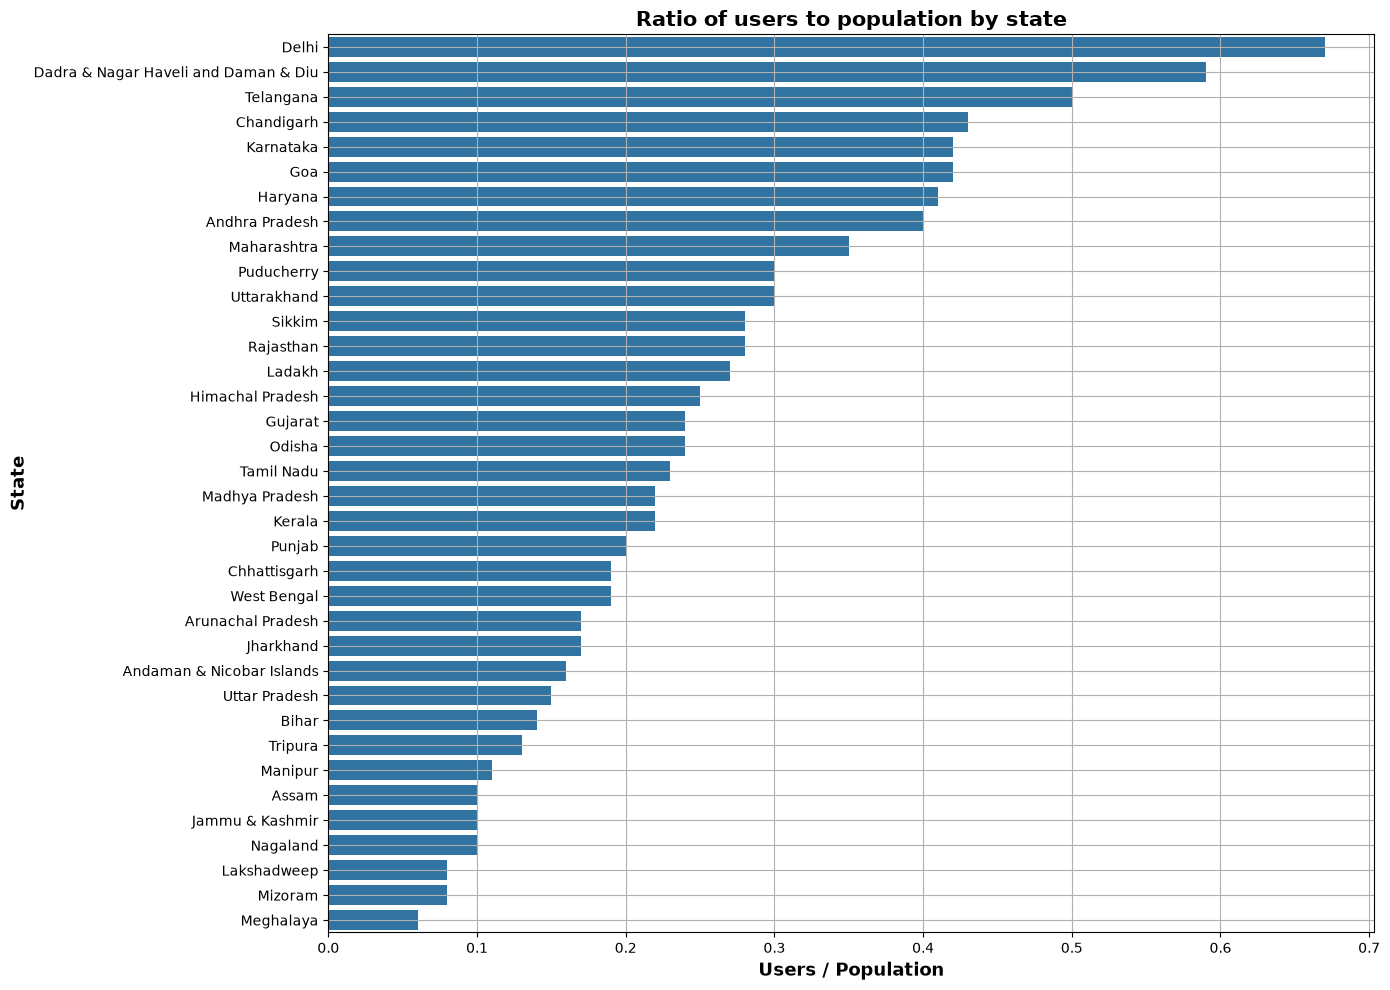

In [345]:
df_state_population_and_users = df_state_population_and_users.sort_values(
    by="users/population", ascending=False
)

plt.figure(figsize=(14, 10))

sns.barplot(df_state_population_and_users, x="users/population", y="State")

plt.ylabel("State", fontsize=13, fontweight="bold")
plt.xlabel("Users / Population", fontsize=13, fontweight="bold")
plt.title(
    "Ratio of users to population by state",
    fontsize=15,
    fontweight="bold",
)

plt.grid()
plt.tight_layout()
plt.show()

---


### **4.2 Correlate population density with transaction volume**


### 4.2.1 Merge the _"District_Txn and Users"_ dataset with the _"District Demographics"_ dataset.


In [346]:
# normalize strings so we don't face Nicobar != nicobar
df_district_transaction_volume = (
    dfs["district_txn_users"].groupby(["State", "District"]).agg({"Transactions": "sum"})
).reset_index()
df_district_transaction_volume[["State", "District"]] = df_district_transaction_volume[
    ["State", "District"]
].apply(lambda col: col.str.title())

df_district_population_density = dfs["district_demographics"][
    ["State", "District", "Density", "Alternate Name"]
].copy()
df_district_population_density[["State", "District", "Alternate Name"]] = (
    df_district_population_density[["State", "District", "Alternate Name"]].apply(
        lambda col: col.str.title()
    )
)
# left-merge using 'State' and 'District' from district demographics
df_merge1 = df_district_transaction_volume.merge(
    df_district_population_density,
    on=["State", "District"],
    how="left",
    indicator=True,
)

# separate out merged and unmerged rows
unmatched_rows = df_merge1[df_merge1["_merge"] == "left_only"][
    ["State", "District", "Transactions"]
]
df_merge1 = df_merge1[df_merge1["_merge"] != "left_only"].drop(columns=["Alternate Name", "_merge"])

# retry unmatched rows using 'Alternate Name' as District from district demographics
df_merge2 = unmatched_rows.merge(
    df_district_population_density.drop(columns="District").rename(
        columns={"Alternate Name": "District"}
    ),
    on=["State", "District"],
    how="left",
    indicator=True,
)

# separate out merged and unmerged rows
df_unmerged = df_merge2[df_merge2["_merge"] == "left_only"].drop(columns="_merge")
df_merge2 = df_merge2[df_merge2["_merge"] != "left_only"].drop(columns="_merge")

display(
    Markdown(
        f"**Total districts from 'District_Txn and Users' dataset:** {len(df_district_transaction_volume)}"
    )
)

print()

display(Markdown(f"**{len(df_unmerged)}** unmerged rows from 'District_Txn and Users' dataset:"))
display(df_unmerged)

df_final_merge = pd.concat([df_merge1, df_merge2], axis=0, ignore_index=True)

display(Markdown(f"Sample of merged data out of total **{len(df_final_merge)}** rows:"))
display(df_final_merge.head())

**Total districts from 'District_Txn and Users' dataset:** 732

**2** unmerged rows from 'District_Txn and Users' dataset:

,State,District,Transactions,Density
38,Jammu & Kashmir,Mirpur,126752,NaN
39,Jammu & Kashmir,Muzaffarabad,10973,NaN


Sample of merged data out of total **730** rows:

,State,District,Transactions,Density
0,Andaman & Nicobar Islands,North And Middle Andaman,149394,28.0
1,Andaman & Nicobar Islands,South Andaman,1014784,89.0
2,Andhra Pradesh,Anantapur,124411535,213.0
3,Andhra Pradesh,Chittoor,181284289,275.0
4,Andhra Pradesh,East Godavari,160754836,477.0


- We calculated total transaction volume, across all quarters for **732** distinct districts from *"District_Txn and Users"* dataset.
- Out of these **732** districts, we managed to find and merge the related population-density column from *"District Demographics"* dataset for **730** rows.
- **2** Jammu & Kashmir districts (Mirpur and Muzaffarabad), didn't have any corresponding entry in *"District Demographics"* despite trying to match with its `District` column as well as `Alternate Name` column.


---


### 4.2.2 Calculate the correlation between population density and transaction volume.


In [347]:
density_transactions_corr_pearson = round(
    df_final_merge["Density"].corr(df_final_merge["Transactions"], method="pearson"), 2
)

display(
    Markdown(
        f"**Pearson correlation between population density and transaction volume:** {density_transactions_corr_pearson}"
    )
)

density_transactions_corr_spearman = round(
    df_final_merge["Density"].corr(df_final_merge["Transactions"], method="spearman"), 2
)

display(
    Markdown(
        f"**Spearman correlation between population density and transaction volume:** {density_transactions_corr_spearman}"
    )
)

**Pearson correlation between population density and transaction volume:** 0.25

**Spearman correlation between population density and transaction volume:** 0.45

- **Pearson method** gives us a value of **0.25** suggesting weak correlation and transaction volume not being driven by population density.
- **Spearman method**, which is less affected by outliers, gives us a value of **0.45** suggesting that the Pearson correlation was probably being suppressed by outlier(s) and there is in fact, a moderately strong correlation between population-density and transaction volume.

---


### 4.2.3 Create a scatter plot to visualize the correlation between population density and transaction volume.


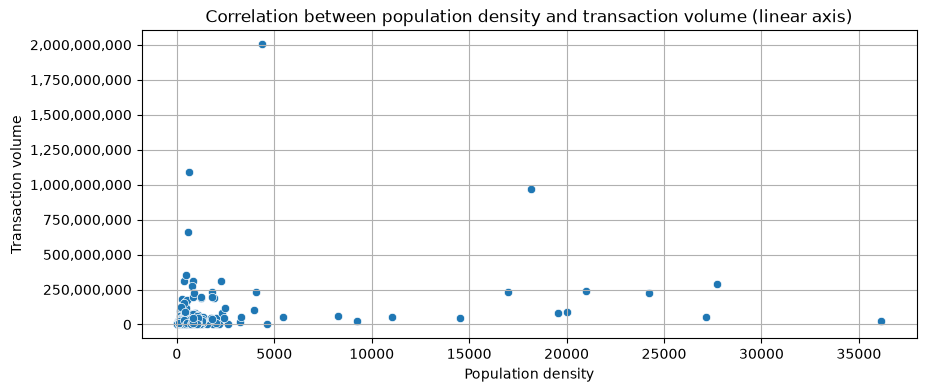

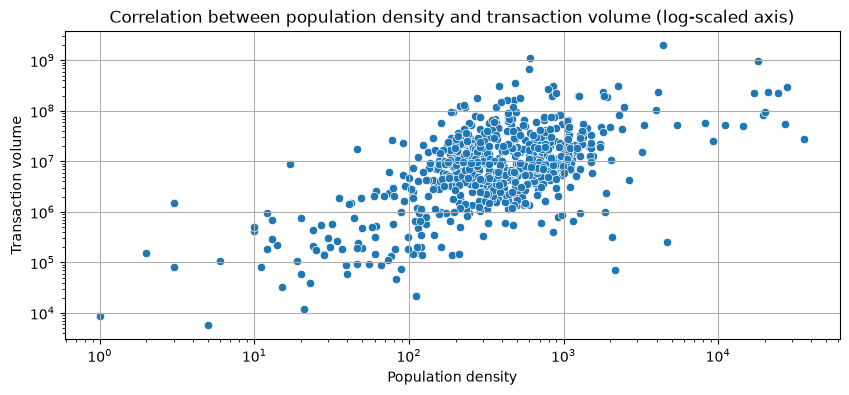

In [348]:
plt.figure(figsize=(10, 4))
sns.scatterplot(df_final_merge, y="Transactions", x="Density")

plt.title("Correlation between population density and transaction volume (linear axis)")
plt.xlabel("Population density")
plt.ylabel("Transaction volume")

# show normal numbers on y axis not scientific notation
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.grid()
plt.show()

# logged chart
plt.figure(figsize=(10, 4))
sns.scatterplot(df_final_merge, y="Transactions", x="Density")

plt.title("Correlation between population density and transaction volume (log-scaled axis)")
plt.xlabel("Population density")
plt.ylabel("Transaction volume")

plt.grid()
plt.yscale("log")
plt.xscale("log")
plt.show()


- In the first chart, we can see most of the points are clustered at the bottom-left which doesn't give us a very clear picture of whats going on, this happens due to both the x-axis and the y-axis being stretched heavily by some outliers.
- Upon re-visualizing the same data with both the axis **using log-scale instead of linear scale**, we get a clearer picture of population density having a moderately positive relationship between population density and transaction volume.
- This also explains why the Spearman correlation (0.45) is noticeably higher than the Pearson correlation (0.25) calculated earlier, the relationship is closer to proportional/multiplicative than strictly linear.

---


### **4.3 Average transaction amount per user**

### 4.3.1 Merge relevant datasets to calculate the average transaction amount per user for each state. Display the results in a tabular format.

In [349]:
df = dfs["state_txn_users"]

df_state_average_transaction_amount = (
    df.groupby("State")
    .agg({"Amount (INR)": "sum", "Registered Users": "max"})
    .rename(columns={"Amount (INR)": "total transaction amount", "Registered Users": "total users"})
    .reset_index()
)

df_state_average_transaction_amount["average transaction amount per user"] = (
    df_state_average_transaction_amount["total transaction amount"]
    / df_state_average_transaction_amount["total users"]
).round(2)

display(Markdown("**Average transaction amount per user for each state:**"))
display(df_state_average_transaction_amount[["State", "average transaction amount per user"]])

**Average transaction amount per user for each state:**

,State,average transaction amount per user
0,Andaman & Nicobar Islands,58649.13
1,Andhra Pradesh,196829.89
2,Arunachal Pradesh,82239.96
3,Assam,77800.49
4,Bihar,109508.70
5,Chandigarh,119740.16
6,Chhattisgarh,85927.35
7,Dadra & Nagar Haveli and Daman & Diu,54084.37
8,Delhi,147544.19
9,Goa,72683.36


***Note:*** *We haven't performed any merge here because `Amount (INR)` and `Registered Users` columns were all we needed to calculate "average transaction amount per user", and both were already present in "State_Txn and Users" dataset.*

---

### 4.3.2 Identify the top 5 states with the highest average transaction amount per user and the top 5 states with the lowest average transaction amount per user. Display the results.

In [350]:
df_state_average_transaction_amount = df_state_average_transaction_amount.sort_values(
    by="average transaction amount per user", ascending=False
)

display(Markdown("**Top 5 states with the highest average transaction amount per user:**"))
display(
    df_state_average_transaction_amount[["State", "average transaction amount per user"]].head(5)
)

df_state_average_transaction_amount = df_state_average_transaction_amount.sort_values(
    by="average transaction amount per user", ascending=True
)

display(Markdown("**Top 5 states with the lowest average transaction amount per user:**"))
display(
    df_state_average_transaction_amount[["State", "average transaction amount per user"]].head(5)
)


**Top 5 states with the highest average transaction amount per user:**

,State,average transaction amount per user
31,Telangana,249864.85
1,Andhra Pradesh,196829.89
15,Karnataka,169367.87
8,Delhi,147544.19
28,Rajasthan,138327.09


**Top 5 states with the lowest average transaction amount per user:**

,State,average transaction amount per user
18,Lakshadweep,39248.10
32,Tripura,44414.66
16,Kerala,50290.68
7,Dadra & Nagar Haveli and Daman & Diu,54084.37
12,Himachal Pradesh,56142.84


---

### **4.4 Device brand usage ratio**

### 4.4.1 Merge the *State_DeviceData* dataset with the *State_Txn and Users* dataset.

In [351]:
df_merged_state_txn_and_device = dfs["state_device_data"].merge(
    dfs["state_txn_users"].rename(columns={"Registered Users": "Registered users(all brands)"}),
    on=[
        "State",
        "Year",
        "Quarter",
    ],
    how="left",
)

display(Markdown("**Sample of merged *`State_DeviceData`* and *`State_Txn and Users`* datasets:**"))
display(df_merged_state_txn_and_device.head(5))

**Sample of merged *`State_DeviceData`* and *`State_Txn and Users`* datasets:**

,State,Year,Quarter,Brand,Registered Users,Percentage,Transactions,Amount (INR),ATV (INR),Registered users(all brands),App Opens
0,Andaman & Nicobar Islands,2018,1,Xiaomi,1665,0.247033,6658,1.463176e+07,2197.621091,6740,NaN
1,Andaman & Nicobar Islands,2018,1,Samsung,1445,0.214392,6658,1.463176e+07,2197.621091,6740,NaN
2,Andaman & Nicobar Islands,2018,1,Vivo,982,0.145697,6658,1.463176e+07,2197.621091,6740,NaN
3,Andaman & Nicobar Islands,2018,1,Oppo,501,0.074332,6658,1.463176e+07,2197.621091,6740,NaN
4,Andaman & Nicobar Islands,2018,1,OnePlus,332,0.049258,6658,1.463176e+07,2197.621091,6740,NaN


---

### 4.4.2 Calculate the ratio of users using each device brand to the total number of registered users in each state. Display the results in a tabular format.

In [352]:
last_year = df_merged_state_txn_and_device["Year"].max()
last_quarter = df_merged_state_txn_and_device[df_merged_state_txn_and_device["Year"] == last_year][
    "Quarter"
].max()

mask_final_quarter = (df_merged_state_txn_and_device["Year"] == last_year) & (
    df_merged_state_txn_and_device["Quarter"] == last_quarter
)

df_merged_final_quarter = df_merged_state_txn_and_device[mask_final_quarter].copy()
df_merged_final_quarter["brand-users to total-users"] = (
    df_merged_final_quarter["Registered Users"]
    / df_merged_final_quarter["Registered users(all brands)"]
)

count_rows_w_different_percentage = (
    df_merged_final_quarter["brand-users to total-users"].round(2)
    != df_merged_final_quarter["Percentage"].round(2)
).sum()

display(
    Markdown(
        f"**Number of rows where our calculated ratio was different than already available `Percentage` column:** {count_rows_w_different_percentage}"
    )
)

display(df_merged_final_quarter[["State", "Brand", "brand-users to total-users"]])

**Number of rows where our calculated ratio was different than already available `Percentage` column:** 0

,State,Brand,brand-users to total-users
143,Andaman & Nicobar Islands,Vivo,0.242467
144,Andaman & Nicobar Islands,Xiaomi,0.238151
145,Andaman & Nicobar Islands,Samsung,0.184814
146,Andaman & Nicobar Islands,Oppo,0.087865
147,Andaman & Nicobar Islands,Realme,0.064965
...,...,...,...
5539,West Bengal,Lenovo,0.019513
5540,West Bengal,Asus,0.016551
5541,West Bengal,Huawei,0.015182
5542,West Bengal,Apple,0.011201


- As discussed earlier, `Registered Users` is cumulative data (because *1.* their total exceeds the population of the state itself and *2.* no instance exists where the number is lower than its previous quarter within the same state), so we've only considered the last year's last quarter's value as "total registered users" for a brand in each state.
- The purpose of this question is a bit confusing, because the ratio we were asked to calculate (as per my understanding) is already available as `Percentage` column in *"State_DeviceData"* and correctly matches the values we calculated.
- Even the merge itself was redundant because registered-users for each brand (including `Others` category for unknown brands) were already present in *"State_DeviceData"* and "total registered users" was simply their sum, and thats all we needed to calculate this ratio asked.

---

### 4.4.3 Create a bar chart depicting the device brand usage ratio for each state.

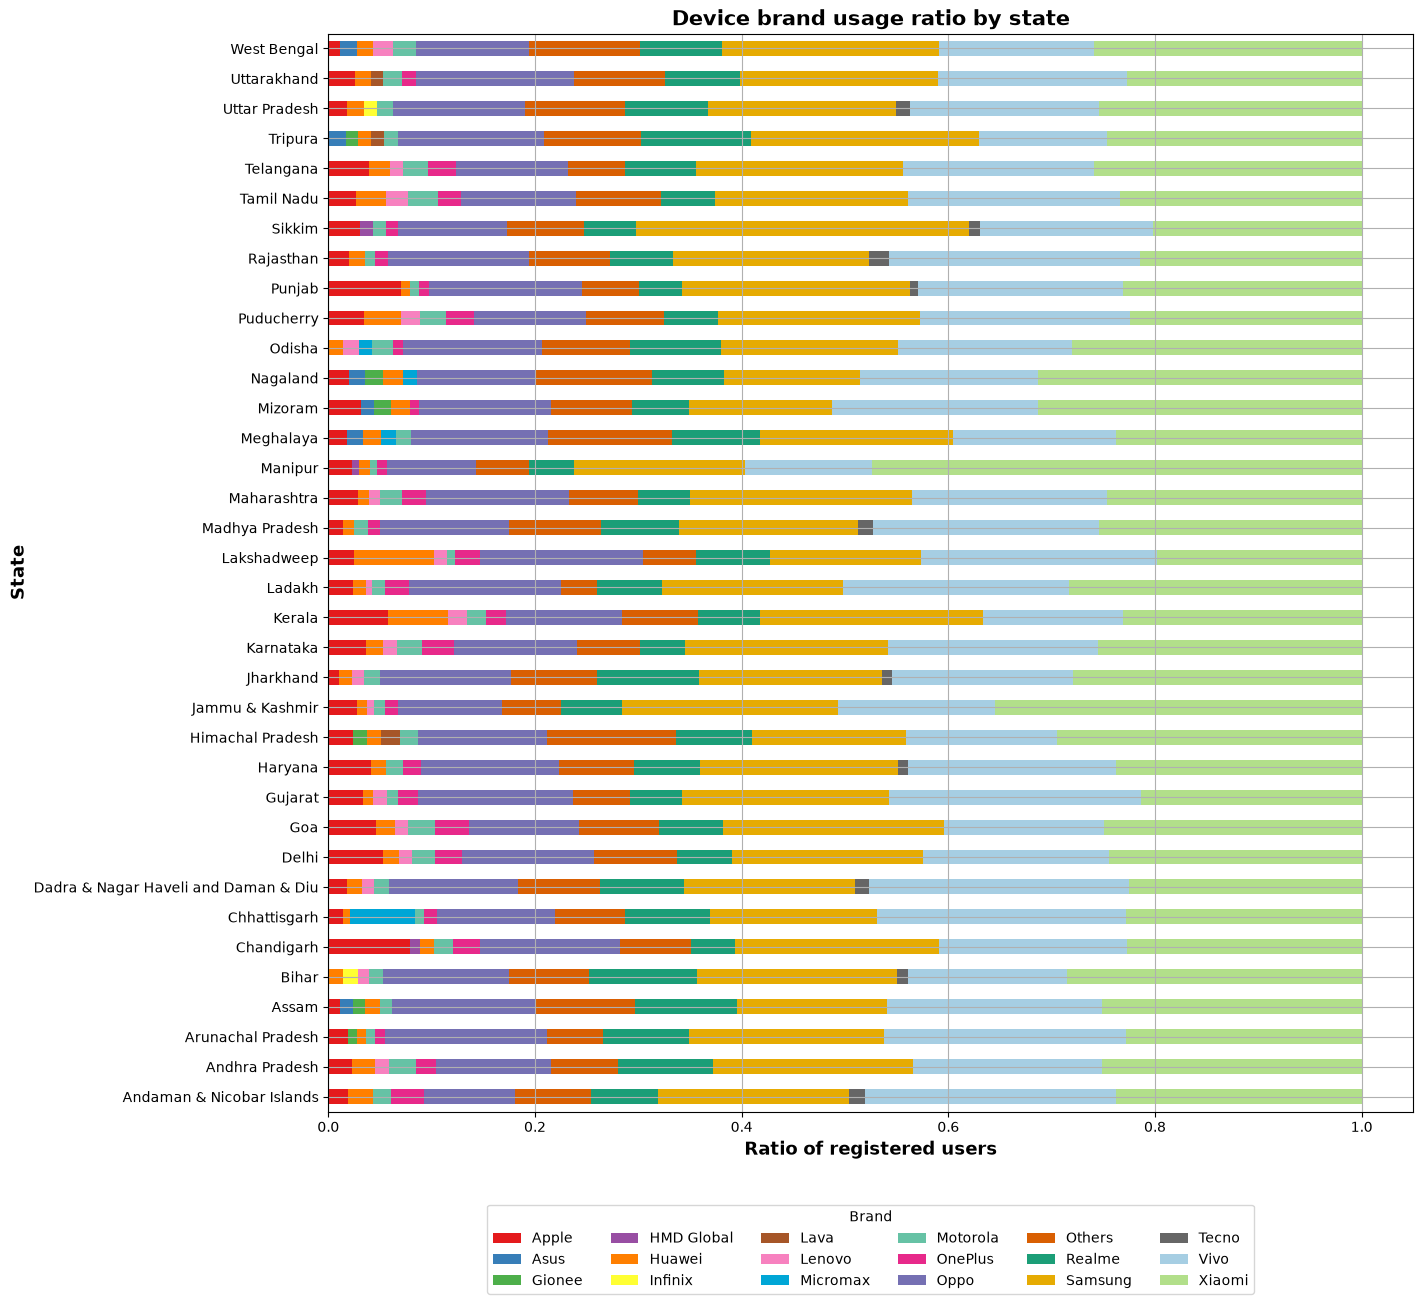

In [ ]:
df_pivot = df_merged_final_quarter.pivot_table(
    index="State", columns="Brand", values="brand-users to total-users", aggfunc="sum"
)

# clearly distinguishable colors unlike the default palette
colors = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#ffff33",
    "#a65628",
    "#f781bf",
    "#00a6d6",
    "#66c2a5",
    "#e7298a",
    "#7570b3",
    "#d95f02",
    "#1b9e77",
    "#e6ab02",
    "#666666",
    "#a6cee3",
    "#b2df8a",
]

df_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 14),
    color=colors,
)

plt.xlabel("Ratio of registered users", fontsize=13, fontweight="bold")
plt.ylabel("State", fontsize=13, fontweight="bold")
plt.title("Device brand usage ratio by state", fontsize=15, fontweight="bold")

plt.legend(title="Brand", loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=6)
plt.grid()
plt.show()

---

# **5. Data Visualization**

### **5.1 Plot the total transactions and amount over time for a selected state**

### 5.1.1 Create a line plot showing the total number of transactions and the total transaction amount over time (years and quarters) for a selected state. 

---

### **5.2 Create a pie chart showing the distribution of transaction types for a specific quarter**

### 5.2.1 Create a pie chart showing the distribution of different transaction types for a selected state and quarter.

---

### **5.3 Visualize the population density of districts in a selected state**

### 5.3.1 Create a bar plot showing the population density of districts in a selected state.

---